Import libraries

In [23]:
import numpy as np
import matplotlib.pyplot as plt

Make (next series) random numbers predictable

In [24]:
np.random.seed(0)

Generate a sample of random numbers drawn from a normal (Gaussian) distribution

In [25]:
# dogs: higher ear flappiness index, lower whisker length
dogs_whisker_length = np.random.normal(loc=5, scale=1, size=10)
dogs_ear_flappiness_index = np.random.normal(loc=8, scale=1, size=10)

In [26]:
# cats: lower ear flappiness index, higher whisker length
cats_whisker_length = np.random.normal(loc=8, scale=1, size=10)
cats_ear_flappiness_index = np.random.normal(loc=5, scale=1, size=10)

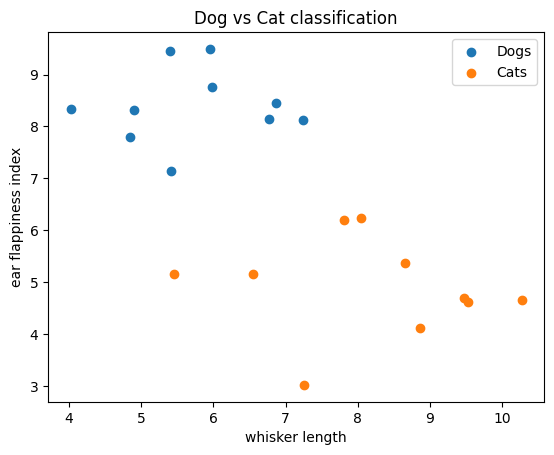

In [27]:
# plot the data points
plt.scatter(dogs_whisker_length, dogs_ear_flappiness_index, label="Dogs")
plt.scatter(cats_whisker_length, cats_ear_flappiness_index, label="Cats")
plt.xlabel("whisker length")
plt.ylabel("ear flappiness index")
plt.title("Dog vs Cat classification")
plt.legend()
plt.show()

In [28]:
# random linear classifier
def random_linear_classifier(data_dogs, data_cats, k, d):
  # d is the number of features
  best_error = float("inf")
  best_theta = None
  best_theta0 = None

  for _ in range(k):
    theta = np.random.normal(size=d)
    theta0 = np.random.normal()

    error = compute_error(data_dogs, data_cats, theta, theta0)

    if error < best_error:
      best_error = error
      best_theta = theta
      best_theta0 = theta0

  return best_theta, best_theta0

In [29]:
def compute_error(data_dogs, data_cats, theta, theta0):
  error = 0
  for x_dog in data_dogs:
    if np.dot(theta, x_dog) + theta0 <= 0:
      error += 1

  for x_cat in data_cats:
    if np.dot(theta, x_cat) + theta0 > 0:
      error += 1

  return error

In [30]:
# prepare data for algorithm
dogs_data = np.vstack((dogs_whisker_length, dogs_ear_flappiness_index)).T
cats_data = np.vstack((cats_whisker_length, cats_ear_flappiness_index)).T

In [31]:
print(">> dogs_data:\n", dogs_data)
print(">> cats_data:\n", cats_data)

>> dogs_data:
 [[6.76405235 8.14404357]
 [5.40015721 9.45427351]
 [5.97873798 8.76103773]
 [7.2408932  8.12167502]
 [6.86755799 8.44386323]
 [4.02272212 8.33367433]
 [5.95008842 9.49407907]
 [4.84864279 7.79484174]
 [4.89678115 8.3130677 ]
 [5.4105985  7.14590426]]
>> cats_data:
 [[ 5.44701018  5.15494743]
 [ 8.6536186   5.37816252]
 [ 8.8644362   4.11221425]
 [ 7.25783498  3.01920353]
 [10.26975462  4.65208785]
 [ 6.54563433  5.15634897]
 [ 8.04575852  6.23029068]
 [ 7.81281615  6.20237985]
 [ 9.53277921  4.61267318]
 [ 9.46935877  4.69769725]]


In [32]:
# run algorithm
k = 100 # number of iterations
d = 2 # number of features
best_theta, best_theta0 = random_linear_classifier(dogs_data, cats_data, k, d)


In [33]:
print(">> best theta: ", best_theta)
print(">> best theta0: ", best_theta0)

>> best theta:  [-1.07075262  1.05445173]
>> best theta0:  -0.40317694697317963


In [34]:
# plot the decision boundary
x_vals = np.linspace(2, 10, 100)
y_vals = (-best_theta[0] / best_theta[1]) * x_vals - (best_theta0 / best_theta[1])

In [35]:
print(">> x vals: ", x_vals)
print(">> y vals: ", y_vals)

>> x vals:  [ 2.          2.08080808  2.16161616  2.24242424  2.32323232  2.4040404
  2.48484848  2.56565657  2.64646465  2.72727273  2.80808081  2.88888889
  2.96969697  3.05050505  3.13131313  3.21212121  3.29292929  3.37373737
  3.45454545  3.53535354  3.61616162  3.6969697   3.77777778  3.85858586
  3.93939394  4.02020202  4.1010101   4.18181818  4.26262626  4.34343434
  4.42424242  4.50505051  4.58585859  4.66666667  4.74747475  4.82828283
  4.90909091  4.98989899  5.07070707  5.15151515  5.23232323  5.31313131
  5.39393939  5.47474747  5.55555556  5.63636364  5.71717172  5.7979798
  5.87878788  5.95959596  6.04040404  6.12121212  6.2020202   6.28282828
  6.36363636  6.44444444  6.52525253  6.60606061  6.68686869  6.76767677
  6.84848485  6.92929293  7.01010101  7.09090909  7.17171717  7.25252525
  7.33333333  7.41414141  7.49494949  7.57575758  7.65656566  7.73737374
  7.81818182  7.8989899   7.97979798  8.06060606  8.14141414  8.22222222
  8.3030303   8.38383838  8.46464646  8.5

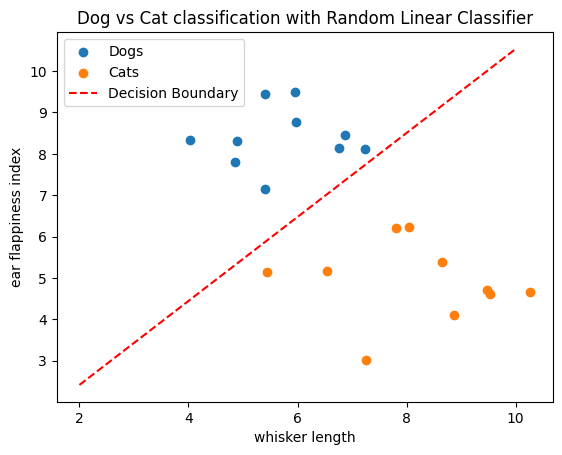

In [36]:
plt.scatter(dogs_whisker_length, dogs_ear_flappiness_index, label = "Dogs")
plt.scatter(cats_whisker_length, cats_ear_flappiness_index, label="Cats")
plt.plot(x_vals, y_vals, color='red', linestyle='--', label="Decision Boundary")
plt.xlabel("whisker length")
plt.ylabel("ear flappiness index")
plt.title("Dog vs Cat classification with Random Linear Classifier")
plt.legend()
plt.show()